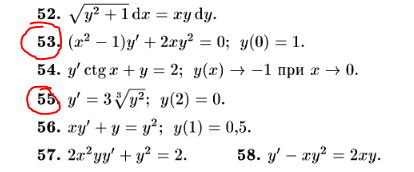

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [ ]:

def m_f_1(x,y):
    return -2*x*y*y/(x**2 - 1)
def m_f_2(x,y):
    return (y**2 - y)/x


def euler_method(f,y0,t_span,h=1e-4):
    t = np.arange(t_span[0], t_span[1] + h, h)
    n = len(t)
    y = np.zeros(n)
    y[0] = y0
    
    for i in range(n-1):
        y[i+1] = y[i] + h * f(t[i], y[i])
    
    return t, y
def rk4_method(f,y0,t_span,h=1e-4):
        t = np.arange(t_span[0], t_span[1] + h, h)
        n = len(t)
        y = np.zeros(n)
        y[0] = y0
        
        for i in range(n-1):
            k1 = h * f(t[i], y[i])
            k2 = h * f(t[i] + h/2, y[i] + k1/2)
            k3 = h * f(t[i] + h/2, y[i] + k2/2)
            k4 = h * f(t[i] + h, y[i] + k3)
            
            y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) / 6
        
        return t, y
def adams_bashforth_4(f,y0,t_span,h=1e-4):
        # Используем RK4 для получения первых 4 точек
        t_rk, y_rk = rk4_method(f,y0,t_span)
        
        # Берем только первые 4 точки для инициализации
        n_total = len(np.arange(t_span[0], t_span[1] + h,h))
        t = np.zeros(n_total)
        y = np.zeros(n_total)

        for i in range(4):
            t[i] = t_rk[i]
            y[i] = y_rk[i]
        

        for i in range(3, n_total-1):
            t[i+1] = t[i] + h
            y[i+1] = y[i] + h * (
                55/24 * f(t[i], y[i]) -
                59/24 * f(t[i-1], y[i-1]) +
                37/24 * f(t[i-2], y[i-2]) -
                9/24 * f(t[i-3], y[i-3])
            )
        
        return t, y

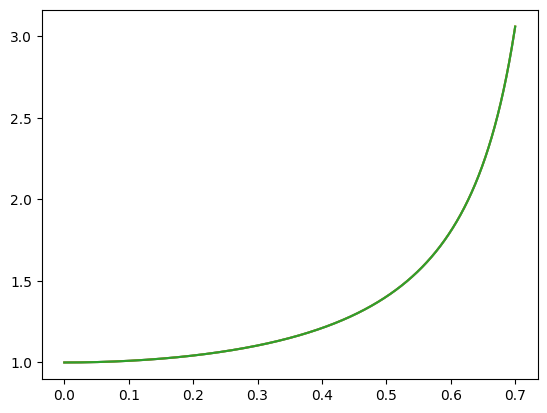

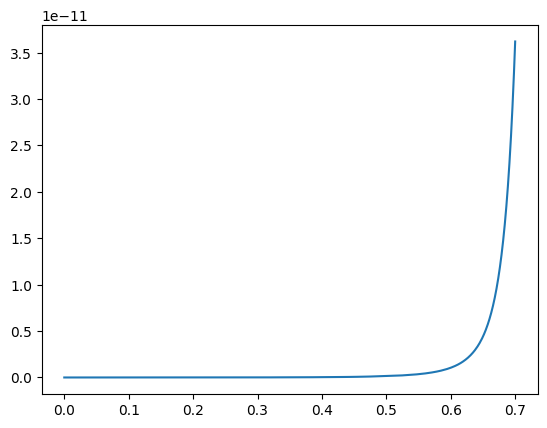

In [23]:
x_1_e,y_1_e = euler_method(m_f_1,1,[0,0.7])
x_1_rk,y_1_rk = rk4_method(m_f_1,1,[0,0.7])
x_1_a,y_1_a = adams_bashforth_4(m_f_1,1,[0,0.7])

plt.plot(x_1_e,y_1_e)
plt.plot(x_1_rk,y_1_rk)
plt.plot(x_1_a,y_1_a)
plt.show()

#plt.plot(x_1_e,np.abs(y_1_e - y_1_rk))
plt.plot(x_1_e,np.abs(y_1_rk - y_1_a))
plt.show()


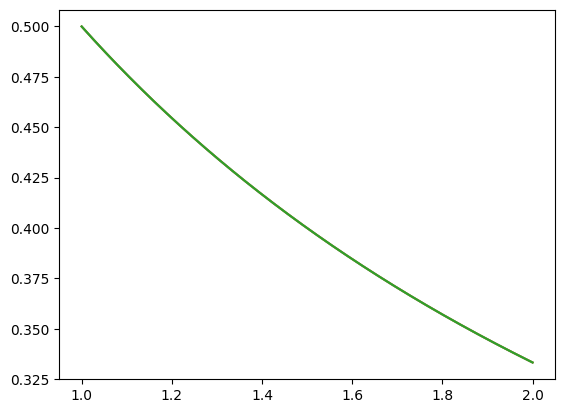

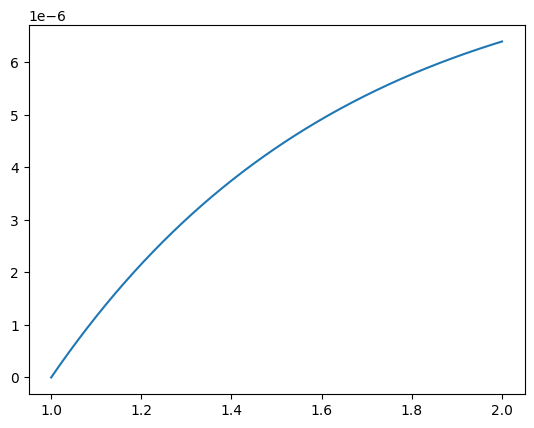

In [26]:
x_2_e,y_2_e = euler_method(m_f_2,0.5,[1,2])
x_2_rk,y_2_rk = rk4_method(m_f_2,0.5,[1,2])
x_2_a,y_2_a = adams_bashforth_4(m_f_2,0.5,[1,2])


plt.plot(x_2_e,y_2_e)
plt.plot(x_2_rk,y_2_rk)
plt.plot(x_2_a,y_2_a)
plt.show()

#plt.plot(x_1_e,np.abs(y_1_e - y_1_rk))
plt.plot(x_2_e,np.abs(y_2_e - y_2_rk))

Решение в Maple


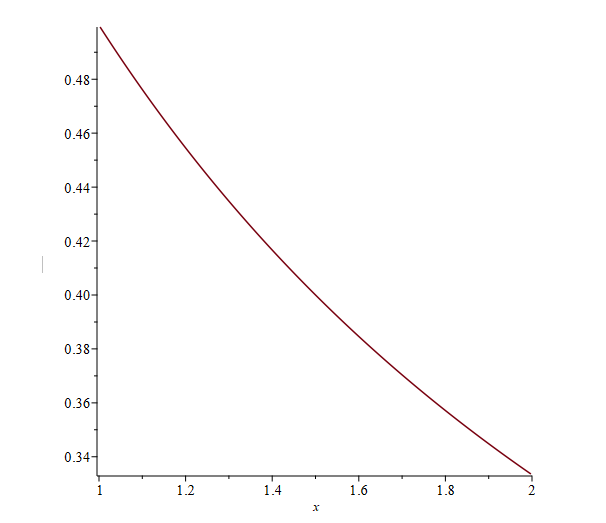

Краевая задача: 
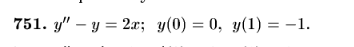


[ 1.28372432e-09 -1.14912750e-04 -2.29826783e-04 ... -9.99862549e-01
 -9.99931280e-01 -1.00000000e+00]


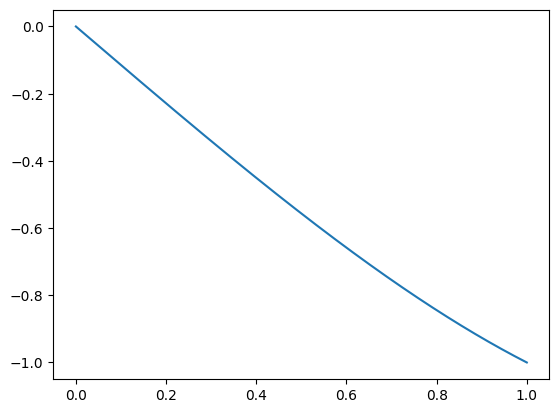

In [36]:
n = 10000
h = 1/n
x = np.arange(0,1,h)
A = np.zeros((n, n))
b = np.zeros(n)


A[0, 0] = 1
y0= 0
b[0] = y0
for i in range(1, n-1):
    A[i, i-1] = 1/h**2
    A[i, i] = -2/h**2 - 1  # -2/h² - 1 (из уравнения y'' - y)
    A[i, i+1] = 1/h**2
    b[i] = 2 * x[i]

# Правое граничное условие: y(x1) = y1
A[-1, -1] = 1
y1 = -1
b[-1] = y1

# Решаем систему линейных уравнений
y = np.linalg.solve(A, b)

print(y)

plt.plot(x,y)

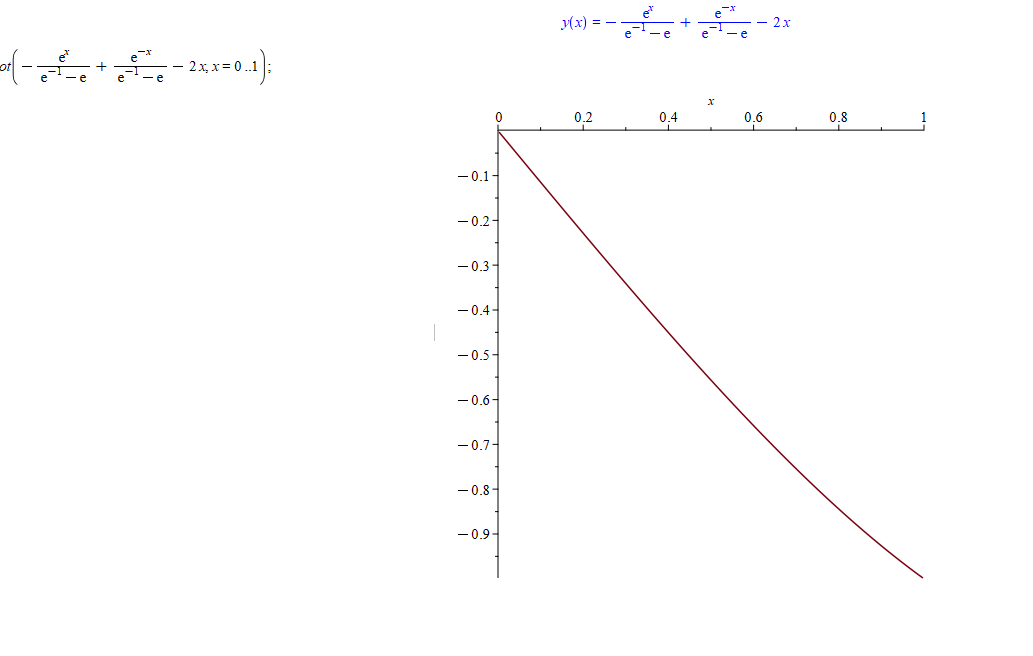